# Notebook 3 - Genetic Algorithm Exam Scheduler

This notebook runs the Genetic Algorithm scheduler using the existing project utilities:

- `utils.data_loader` loads exams, students, rooms, timeslots, and the conflict matrix.
- `utils.constraints` is used inside `utils/GA.py` for fitness evaluation.
- The GA chromosome representation is `{exam_id: {"timeslot": slot_id, "room": room_id}}`.

Important data note: the largest exam has more students than any single room can hold. The current `utils/constraints.py` file does not include a capacity constraint or multi-room split representation, so this notebook optimizes only the constraint functions that actually exist in the project.

## Step 0 - Imports and Paths

In [1]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CONFLICT_MATRIX_PATH = OUTPUT_DIR / "conflict_matrix.pkl"

from utils.data_loader import (
    build_conflict_matrix,
    load_conflict_matrix,
    load_exams,
    load_rooms,
    load_students,
    load_timeslots,
)
import importlib
import utils.constraints as constraints_module
importlib.reload(constraints_module)
import utils.GA as ga_module
importlib.reload(ga_module)

GeneticExamScheduler = ga_module.GeneticExamScheduler
export_schedule_rows = ga_module.export_schedule_rows
format_schedule_table = ga_module.format_schedule_table

## Step 1 - Load Real Project Data

In [2]:
exams = load_exams(path=str(DATA_DIR / "data.csv"))
students = load_students(path=str(DATA_DIR / "IDs.csv"))
rooms = load_rooms(path=str(DATA_DIR / "rooms.csv"))
timeslots = load_timeslots()

OUTPUT_DIR.mkdir(exist_ok=True)
try:
    conflict_matrix = load_conflict_matrix(path=str(CONFLICT_MATRIX_PATH))
except FileNotFoundError:
    conflict_matrix = build_conflict_matrix(exams, save_path=str(CONFLICT_MATRIX_PATH))

Loaded 235 exams.
Loaded 4265 students.
Loaded 38 usable rooms.
Generated 60 timeslots across 15 working days.
Conflict matrix loaded from C:\Users\SDS Scholar\Desktop\AI Project - Copy\outputs\conflict_matrix.pkl


## Step 2 - Confirm Data Shape

In [3]:
summary = pd.DataFrame(
    [
        ["Exams", len(exams)],
        ["Students", len(students)],
        ["Usable rooms", len(rooms)],
        ["Timeslots", len(timeslots)],
        ["Conflict pairs", sum(len(v) for v in conflict_matrix.values()) // 2],
        ["Largest exam size", max(info["num"] for info in exams.values())],
        ["Largest room capacity", max(room["capacity"] for room in rooms)],
    ],
    columns=["Item", "Value"],
)
display(summary)

display(pd.DataFrame(rooms).head())
display(pd.DataFrame(timeslots).head())

,Item,Value
0,Exams,235
1,Students,4265
2,Usable rooms,38
3,Timeslots,60
4,Conflict pairs,2702
5,Largest exam size,472
6,Largest room capacity,69


,room_id,building,capacity
0,1,Tarek Khalil,33
1,7,Tarek Khalil,33
2,8,Tarek Khalil,33
3,9,Tarek Khalil,33
4,52,Tarek Khalil,33


,slot_id,date,day,time
0,0,2025-05-31,Saturday,08:00-10:00
1,1,2025-05-31,Saturday,10:00-12:00
2,2,2025-05-31,Saturday,12:00-14:00
3,3,2025-05-31,Saturday,14:00-16:00
4,4,2025-06-01,Sunday,08:00-10:00


## Step 3 - GA Hyperparameters

In [4]:
POPULATION_SIZE = 80
GENERATIONS = 150
MUTATION_RATE = 0.08
CROSSOVER_RATE = 0.85
ELITE_SIZE = 4
TOURNAMENT_SIZE = 4
SEED = 42

## Step 4 - Initialize Scheduler

In [5]:
scheduler = GeneticExamScheduler(
    exams=exams,
    rooms=rooms,
    timeslots=timeslots,
    conflict_matrix=conflict_matrix,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE,
    seed=SEED,
)

## Step 5 - Run Evolution

In [6]:
best_chromosome, result, history = scheduler.evolve(verbose=True)

Generation    1: best=  84800 avg=  75732 hard=  15 soft=  4
Generation   10: best=  87900 avg=  78419 hard=  12 soft=  2
Generation   20: best=  90900 avg=  78750 hard=   9 soft=  2
Generation   30: best=  90900 avg=  79270 hard=   9 soft=  2
Generation   40: best=  90900 avg=  78927 hard=   9 soft=  2
Generation   50: best=  90900 avg=  80388 hard=   9 soft=  2
Generation   60: best=  90900 avg=  80381 hard=   9 soft=  2
Generation   70: best=  92750 avg=  80905 hard=   7 soft=  5
Generation   80: best=  92750 avg=  79841 hard=   7 soft=  5
Generation   90: best=  92750 avg=  80135 hard=   7 soft=  5
Generation  100: best=  92750 avg=  78896 hard=   7 soft=  5
Generation  110: best=  92750 avg=  80130 hard=   7 soft=  5
Generation  120: best=  92750 avg=  81723 hard=   7 soft=  5
Generation  130: best=  92750 avg=  81247 hard=   7 soft=  5
Generation  140: best=  92750 avg=  79965 hard=   7 soft=  5
Generation  150: best=  92750 avg=  81428 hard=   7 soft=  5


## Step 6 - Fitness Statistics

In [7]:
stats = pd.DataFrame(
    [
        ["Best fitness", result.fitness],
        ["Hard violations", result.hard_violations],
        ["Room double-bookings", result.room_double_bookings],
        ["Student same-timeslot clashes", result.student_clashes],
        ["Room capacity violations", result.room_capacity_violations],
        ["Student same-day clashes", result.same_day_student_clashes],
        ["Soft violations", result.soft_violations],
        ["Uneven day distribution", result.uneven_day_distribution],
    ],
    columns=["Metric", "Value"],
)
display(stats) 

,Metric,Value
0,Best fitness,92750
1,Hard violations,7
2,Room double-bookings,0
3,Student same-timeslot clashes,1
4,Room capacity violations,0
5,Student same-day clashes,6
6,Soft violations,5
7,Uneven day distribution,5


## Step 7 - Final Schedule

In [8]:
schedule_rows = export_schedule_rows(best_chromosome, exams, rooms, timeslots)
schedule_df = pd.DataFrame(schedule_rows)
display(schedule_df)

schedule_output_path = OUTPUT_DIR / "ga_schedule.csv"
if pd.api.types.is_datetime64_any_dtype(schedule_df["date"]):
    schedule_df["date"] = schedule_df["date"].dt.strftime('%Y-%m-%d')
else:
    schedule_df["date"] = schedule_df["date"].astype(str)
schedule_df.to_csv(schedule_output_path, index=False, encoding="utf-8-sig", quoting=csv.QUOTE_NONNUMERIC)
schedule_output_path

,exam,total students,room,room capacity,students in room,student ids,date,day,time
0,CSC103,288,330B,68,68,251000447+251000547+251000761+251000888+251000...,2025-05-31,Saturday,08:00-10:00
1,CSC103,288,F45,68,68,251002803+251002833+251002860+251002934+251002...,2025-05-31,Saturday,08:00-10:00
2,CSC103,288,F46,68,68,251002371+251002480+251002483+251002511+251002...,2025-05-31,Saturday,08:00-10:00
3,CSC103,288,F48,67,67,251000956+251000991+251001029+251001044+251001...,2025-05-31,Saturday,08:00-10:00
4,CSC103,288,111,66,17,251000341+251000473+251000492+251000520+251000...,2025-05-31,Saturday,08:00-10:00
...,...,...,...,...,...,...,...,...,...
405,IND324,17,F48,67,17,1820029+202002077+202002999+211001020+22100015...,2025-06-16,Monday,14:00-16:00
406,MATH110B,40,134,66,40,202001301+211000318+221000341+231002108+231002...,2025-06-16,Monday,14:00-16:00
407,SSCI102,144,330A,69,69,18102520+19100361+19200031+202000665+202001162...,2025-06-16,Monday,14:00-16:00
408,SSCI102,144,129,68,68,221000014+221000507+221001354+231000221+231000...,2025-06-16,Monday,14:00-16:00


WindowsPath('C:/Users/SDS Scholar/Desktop/AI Project - Copy/outputs/ga_schedule.csv')

## Step 8 - Convergence Plot

,generation,best_fitness,average_fitness,hard_violations,soft_violations
145,146,92750,80424,7,5
146,147,92750,81212,7,5
147,148,92750,81416,7,5
148,149,92750,80788,7,5
149,150,92750,81428,7,5


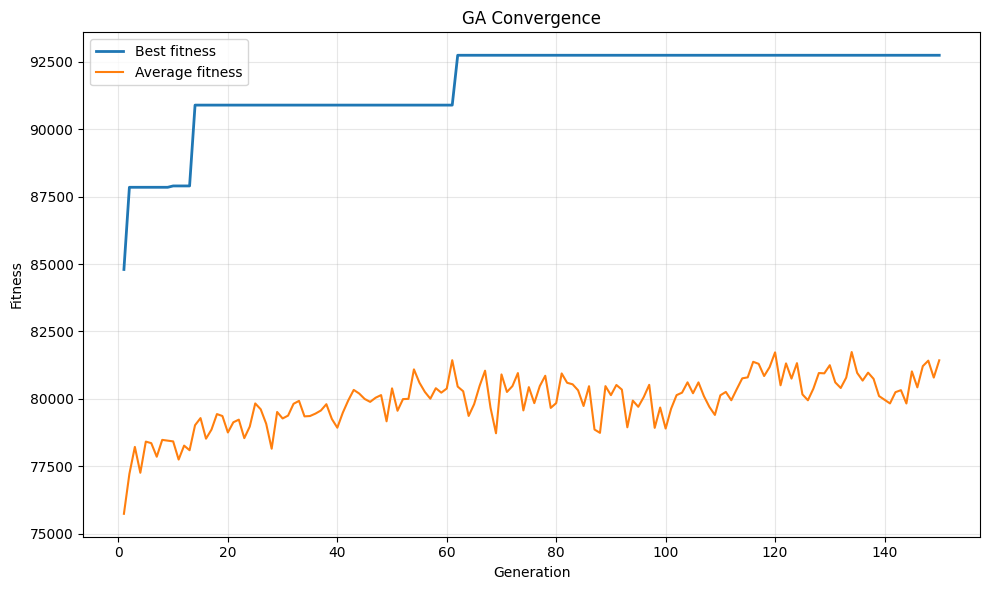

In [9]:
history_df = pd.DataFrame(history)
display(history_df.tail())

plt.figure(figsize=(10, 6))
plt.plot(history_df["generation"], history_df["best_fitness"], label="Best fitness", linewidth=2)
plt.plot(history_df["generation"], history_df["average_fitness"], label="Average fitness", linewidth=1.5)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("GA Convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

## Step 9 - Schedule Visuals

,date,day,exam count
0,2025-05-31,Saturday,13
1,2025-06-01,Sunday,12
2,2025-06-02,Monday,19
3,2025-06-03,Tuesday,18
4,2025-06-04,Wednesday,17
5,2025-06-05,Thursday,18
6,2025-06-07,Saturday,19
7,2025-06-08,Sunday,12
8,2025-06-09,Monday,13
9,2025-06-10,Tuesday,16


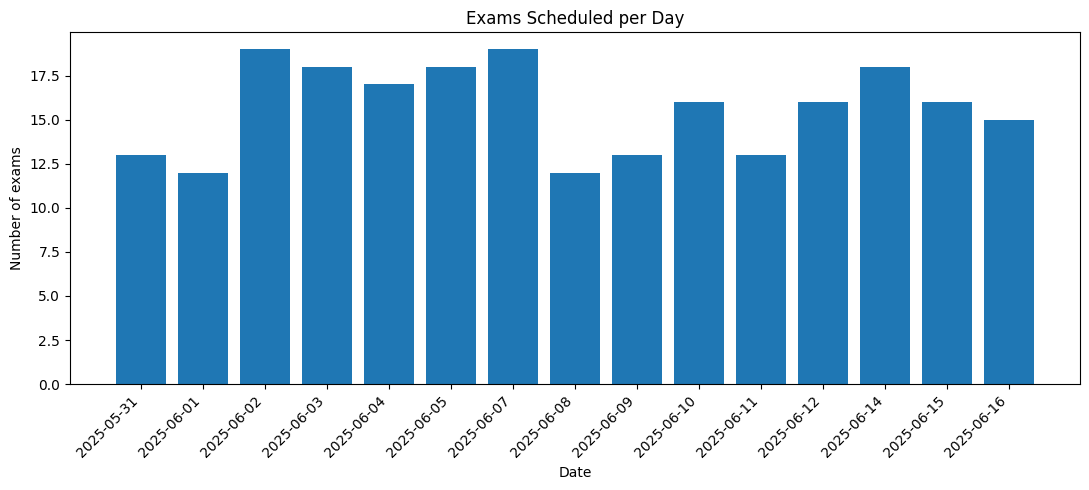

In [10]:
dated_rows = schedule_df[schedule_df["date"] != "###"].copy()

exams_per_day = dated_rows.groupby(["date", "day"])["exam"].nunique().reset_index(name="exam count")
display(exams_per_day)

plt.figure(figsize=(11, 5))
plt.bar(exams_per_day["date"], exams_per_day["exam count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Number of exams")
plt.title("Exams Scheduled per Day")
plt.tight_layout()
plt.show()


,exam,rooms used
95,ECE151,7
212,MTH113,7
68,CSCI315,6
231,PHY112,6
62,CSCI208,5
65,CSCI305,5
64,CSCI217,5
57,CSC103,5
77,CSCI467,5
71,CSCI417,5


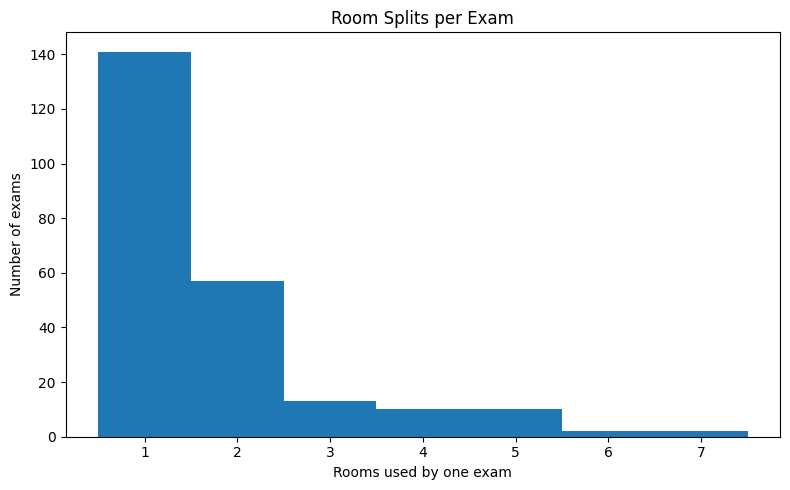

In [11]:
rooms_per_exam = schedule_df.groupby("exam")["room"].nunique().reset_index(name="rooms used")
display(rooms_per_exam.sort_values("rooms used", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.hist(rooms_per_exam["rooms used"], bins=range(1, int(rooms_per_exam["rooms used"].max()) + 2), align="left")
plt.xlabel("Rooms used by one exam")
plt.ylabel("Number of exams")
plt.title("Room Splits per Exam")
plt.tight_layout()
plt.show()


,room,allocations
0,330A,60
1,129,59
2,306,58
3,330B,50
4,F45,42
5,F46,35
6,F48,29
7,111,19
8,116,16
9,134,13


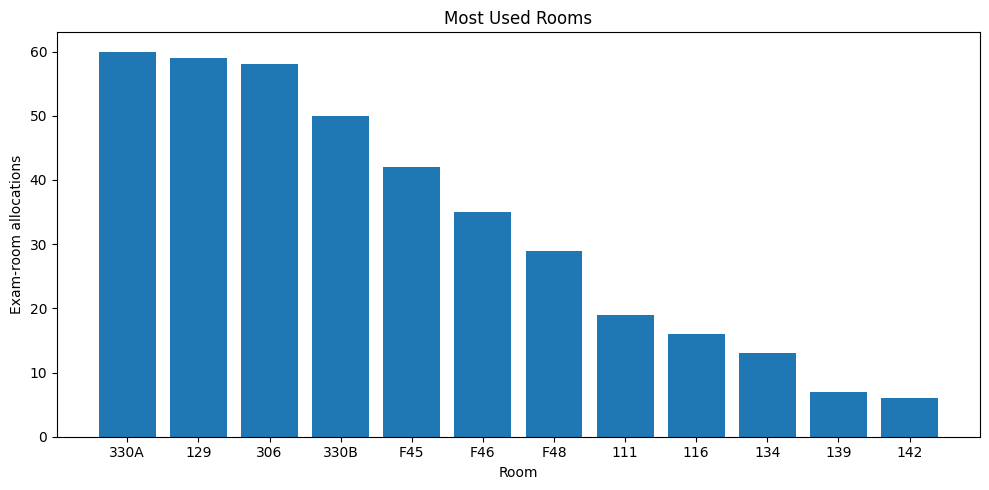

In [12]:
room_usage = schedule_df.groupby("room")["exam"].count().sort_values(ascending=False).head(12)
display(room_usage.reset_index(name="allocations"))

plt.figure(figsize=(10, 5))
plt.bar(room_usage.index.astype(str), room_usage.values)
plt.xlabel("Room")
plt.ylabel("Exam-room allocations")
plt.title("Most Used Rooms")
plt.tight_layout()
plt.show()


## Optional - Inspect the Raw Chromosome

In [13]:
dict(list(best_chromosome.items())[:5])

{'HUMA001/101 (Room)': {'timeslot': 2,
  'rooms': ['330A', '129', '306', '330B']},
 'SSCI102': {'timeslot': 59, 'rooms': ['330A', '129', '306']},
 'HUMA102': {'timeslot': 9, 'rooms': ['330A', '129', '306']},
 'NSCI102': {'timeslot': 13, 'rooms': ['330A', '129', '306']},
 'SSCI201': {'timeslot': 52, 'rooms': ['330A', '129']}}